In [17]:
## IMPORTS
# Import core libraries for data manipulation (pandas, numpy), 
# visualization (matplotlib, seaborn), 
# and modeling (scikit-learn pipeline components, logistic regression, and evaluation metrics).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    roc_auc_score
)

In [18]:
## LOAD AND PREVIEW DATA
# Load the raw Telco Customer Churn CSV, 
# drop the non-predictive `customerID` column, 
# and preview the first 5 rows to confirm structure.


df_original= pd.read_csv(r"C:\Projects\telco-churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
pd.set_option("display.max_columns", None)
df = df_original.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
## SHAPE AND MISSING VALUES
# Check dataset dimensions and confirm there are no null values across all 20 columns.

print(df.shape)
print(df.isnull().sum())

(7043, 20)
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [20]:
## UNIQUE VALUE COUNTS
# Check the number of unique values per column to understand cardinality. 
# Helps distinguish binary columns (2 unique), low-cardinality categoricals, 
# and high-cardinality numerics like `TotalCharges` (6,531 unique values).

print(df.nunique())

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [21]:
## DATA TYPES
# Inspect column dtypes. Key finding: `TotalCharges` is typed as `object` instead of `float64`, 
# meaning it contains non-numeric characters (likely whitespace) 
# and will need to be coerced before modeling.

print(df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [22]:
## FEATURE/TARGET SPLIT AND TRAIN-TEST SPLIT
# Coerce `TotalCharges` to numeric (non-parseable values become NaN). 
# Map the target column `Churn` to binary (Yes → 1, No → 0). 
# Split into 80/20 train/test sets with stratification to preserve the class imbalance ratio.

X = df.drop("Churn", axis=1)
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")
X = X.dropna(subset=["TotalCharges"])

y = df["Churn"]
y = y.map({"Yes": 1, "No": 0})
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
    )

In [23]:
## IDENTIFY COLUMN TYPES
# Separate columns into three groups for the preprocessor: 
# categorical (object dtype), continuous numeric (int/float with more than 2 unique values), 
# and binary numeric (int/float with exactly 2 unique values). 
# Binary columns are excluded from scaling since they're already 0/1.

num_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_columns = X_train.select_dtypes(include=["str"]).columns.tolist()

binary_columns = [col for col in num_columns if X_train[col].nunique() == 2]

num_columns = [col for col in num_columns if col not in binary_columns]

In [24]:
## BUILD PREPROCESSOR 
# Construct a ColumnTransformer that applies One-Hot Encoding (dropping the first category to avoid multicollinearity) to categorical columns, 
# Standard Scaling to continuous numeric columns, 
# and passes binary columns through unchanged.

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_columns),
        ("num", StandardScaler(), num_columns),
        ("bin", "passthrough", binary_columns)
    ]
)

In [25]:
## BUILD PIPELINE
# Combine the preprocessor and a Logistic Regression model into a single sklearn Pipeline, 
# ensuring preprocessing is always applied consistently to any data passed through.

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, solver="liblinear", l1_ratio=1))
])

In [26]:
## DEFINE HYPERPARAMETER SEARCH SPACE
# Define the parameter grid for GridSearchCV.
# Searches over regularization strength C using the liblinear solver with l1 penalty.

param_distributions = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
}

In [27]:
## INSTANTIATE AND FIT SEARCH
# Run GridSearchCV over all 12 hyperparameter combinations (C, penalty, solver).
# Uses 5-fold cross-validation scored on ROC AUC to find the best pipeline configuration.

search = GridSearchCV(
    pipeline,
    param_distributions,
    cv=5,
    scoring="roc_auc")

search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [28]:
## EVALUATING BEST HYPERPARAMETERS
# Print best hyperparameter combination as identified by GridSearchCV
# Print best ROC AUC score from training data across all 5 cross-validation folds

print(search.best_params_)
print(search.best_score_)

{'model__C': 100}
0.8462157959947202


In [29]:
## GENERATE PREDICTIONS
# Extract the best-performing pipeline from GridSearchCV into best_model
# Predict class labels for each customer with y_pred
# Predict churn probability for each customer with y_prob

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [30]:
## CONFUSION MATRIX METRIC EVALUATION
# Creating variable for finding false positives and negatives using the models predicted labels vs actual labels
# The model has a slight bias towards predicting less churn than reality, as indicated by the higher number of false negatives vs false positives

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[910 123]
 [162 212]]


In [31]:
## CLASSIFICATION REPORT EVALUATION
# Breaks down precision, recall, and F1-score for each class using hard predictions.
# Model performs stronger on class 0 (0.86 F1) than class 1 (0.60 F1), reflecting the class imbalance in the dataset.

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



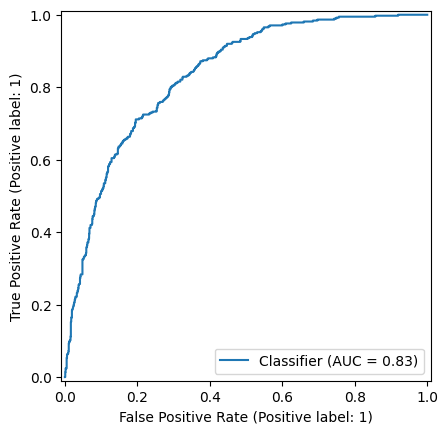

ROC AUC Score: 0.834986876912166


In [32]:
## ROC CURVE AND ROC AUC SCORE
# Plots true positive rate vs false positive rate across all classification thresholds.
# AUC of 0.84 indicates the model correctly ranks a churner above a non-churner 84% of the time.

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

## Overall Model Metrics Evaluation
### Confusion Matrix and Classification Report
The confusion matrix shows a bias towards false negatives as the model is 32% more likely to incorrectly classify someone as a churner despite actually being so. This is a flaw in the model because given the business context, the cost of losing a customer is greater than the loss of giving discounts a non-churner. This bias is common in datasets that have a large class imbalance, such as churn datasets where the majority of users are non-churners. Corrections to mitigate this bias include using SMOTE, or by lowering the classification threshold. The classification report shows an f-1 score of 0.86 for non-churners and 0.60 for churners, further proving the bias towards false negatives due to class imbalance in the dataset.


### ROC AUC Score
This model has an 83.50% chance of correctly ranking a churner over a non-churner when evaluated on testing data. The model scored a 84.62% ROC AUC score when using its best parameter combination on our training data. The relatively small difference of 1.12% indicates a healthy lack of overfitting, while still producing solid ROC AUC scores that show little underfitting. 

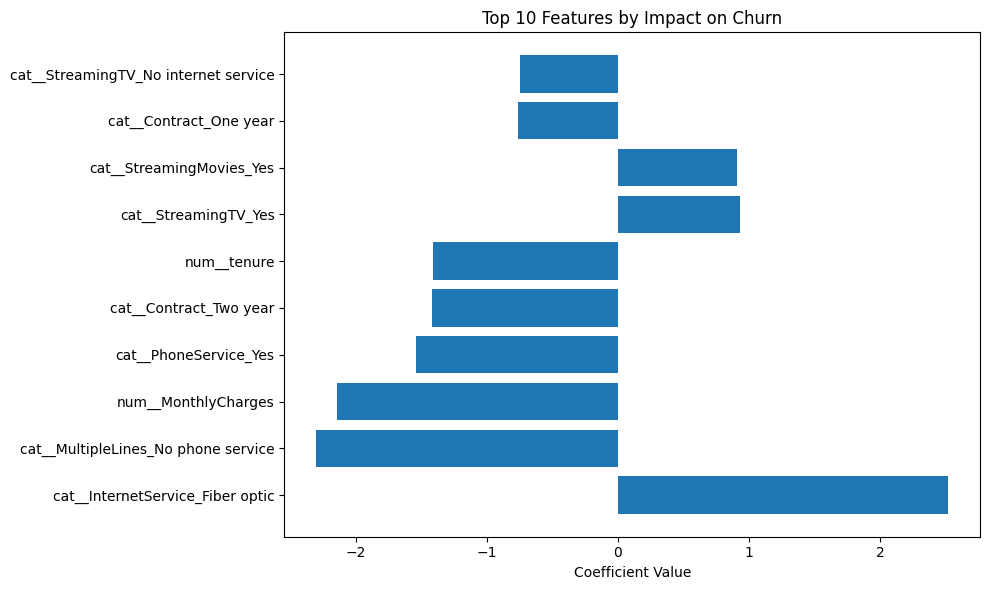

In [ ]:
## FEATURE IMPORTANCE
# Extracts logistic regression coefficients to identify which features most influenced churn predictions.
# Positive coefficients increase churn probability, negative coefficients decrease it.

coefficients = best_model.named_steps["model"].coef_[0]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Top 10 Features by Impact on Churn")
plt.tight_layout()
plt.show()